In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df_train = pd.read_csv(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_train.csv" , header = None)

df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2064 entries, 0 to 2063
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       2064 non-null   str    
 1   1       2064 non-null   float64
 2   2       2064 non-null   int64  
 3   3       2064 non-null   float64
 4   4       2064 non-null   float64
 5   5       2064 non-null   float64
 6   6       2064 non-null   float64
 7   7       2064 non-null   float64
 8   8       2064 non-null   float64
 9   9       2064 non-null   float64
 10  10      2064 non-null   float64
 11  11      2064 non-null   float64
 12  12      2064 non-null   float64
 13  13      2064 non-null   float64
 14  14      2064 non-null   float64
 15  15      2064 non-null   float64
 16  16      2064 non-null   float64
 17  17      2064 non-null   float64
 18  18      2064 non-null   float64
 19  19      2064 non-null   float64
 20  20      2064 non-null   float64
 21  21      2064 non-null   float64
 22  22      206

In [3]:
df_train.isnull().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
dtype: int64

In [4]:
df_train.head(2)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,001197_M_18_180340_5443109.jpg,16.736433,1,0.76096,0.485597,0.800905,1.612940,2.013897,4.980746,4.105896,...,19.905191,0.0,0.0,20.950941,20.478027,0.0,0.0,18,1.8034,54.43109
1,0_M_33_187960_19277677.jpg,54.566215,1,1.23708,2.747253,1.146789,2.819359,2.458481,1.529249,2.262845,...,39.689133,0.0,0.0,40.617210,39.593468,0.0,0.0,33,1.8796,192.77677


In [5]:
df_train.iloc[0, [0, 1, 2, 25, 26, 27]]


0     001197_M_18_180340_5443109.jpg
1                          16.736433
2                                  1
25                                18
26                            1.8034
27                          54.43109
Name: 0, dtype: object

In [6]:
#Test Data

In [7]:
df_test_raw = pd.read_csv(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_test.csv", header=None)

In [8]:
## Extrating the Image name, bmi Gender, age , height, weight

In [9]:
df_clean = df_train[[0, 1, 2, 25, 26, 27]].copy()

In [10]:
df_clean.columns = ['image_name', 'bmi', 'gender', 'age', 'height', 'weight']

In [11]:
df_clean.head()

,image_name,bmi,gender,age,height,weight
0,001197_M_18_180340_5443109.jpg,16.736433,1,18,1.8034,54.43109
1,0_M_33_187960_19277677.jpg,54.566215,1,33,1.8796,192.77677
2,000558_M_33_172720_11403313.jpg,38.224850,1,33,1.7272,114.03313
3,000614_M_40_175260_9071848.jpg,29.534536,1,40,1.7526,90.71848
4,000728_F_28_167640_8391459.jpg,29.859475,0,28,1.6764,83.91459


In [12]:
#converting height from meter to cm 

In [13]:
df_clean['height_cm'] = df_clean['height'] * 100

In [14]:
df_clean = df_clean.drop(columns=['height'])

In [15]:
df_clean.isnull().sum()

image_name    0
bmi           0
gender        0
age           0
weight        0
height_cm     0
dtype: int64

In [16]:
df_clean.describe()

,bmi,gender,age,weight,height_cm
count,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000
mean,30.581077,0.500000,26.757752,91.630253,172.706586
std,9.077824,0.500121,6.064801,30.266501,10.696066
min,10.493576,0.000000,15.000000,29.483510,127.000000
25%,24.393785,0.000000,22.000000,71.667590,165.100000
50%,28.321894,0.500000,26.000000,83.914590,172.720000
75%,34.456521,1.000000,30.000000,104.326250,180.340000
max,78.614719,1.000000,56.000000,254.011740,200.660000


In [17]:
# Same Operations on Test data

In [18]:
df_test = df_test_raw[[0, 1, 2, 25, 26, 27]].copy()

df_test.columns = ['image_name', 'bmi', 'gender', 'age', 'height_m', 'weight'] 

df_test['height_cm'] = df_test['height_m'] * 100
df_test = df_test.drop(columns=['height_m'])

In [19]:
# Data Exploration

In [20]:
for col in ['bmi', 'height_cm', 'weight']:
    mean_val = df_clean[col].mean()
    print(f"Target {col}: Naive prediction is {mean_val:.2f}")

Target bmi: Naive prediction is 30.58
Target height_cm: Naive prediction is 172.71
Target weight: Naive prediction is 91.63


In [21]:
df_clean['gender'].value_counts()

gender
1    1032
0    1032
Name: count, dtype: int64

In [22]:
## Visualisation

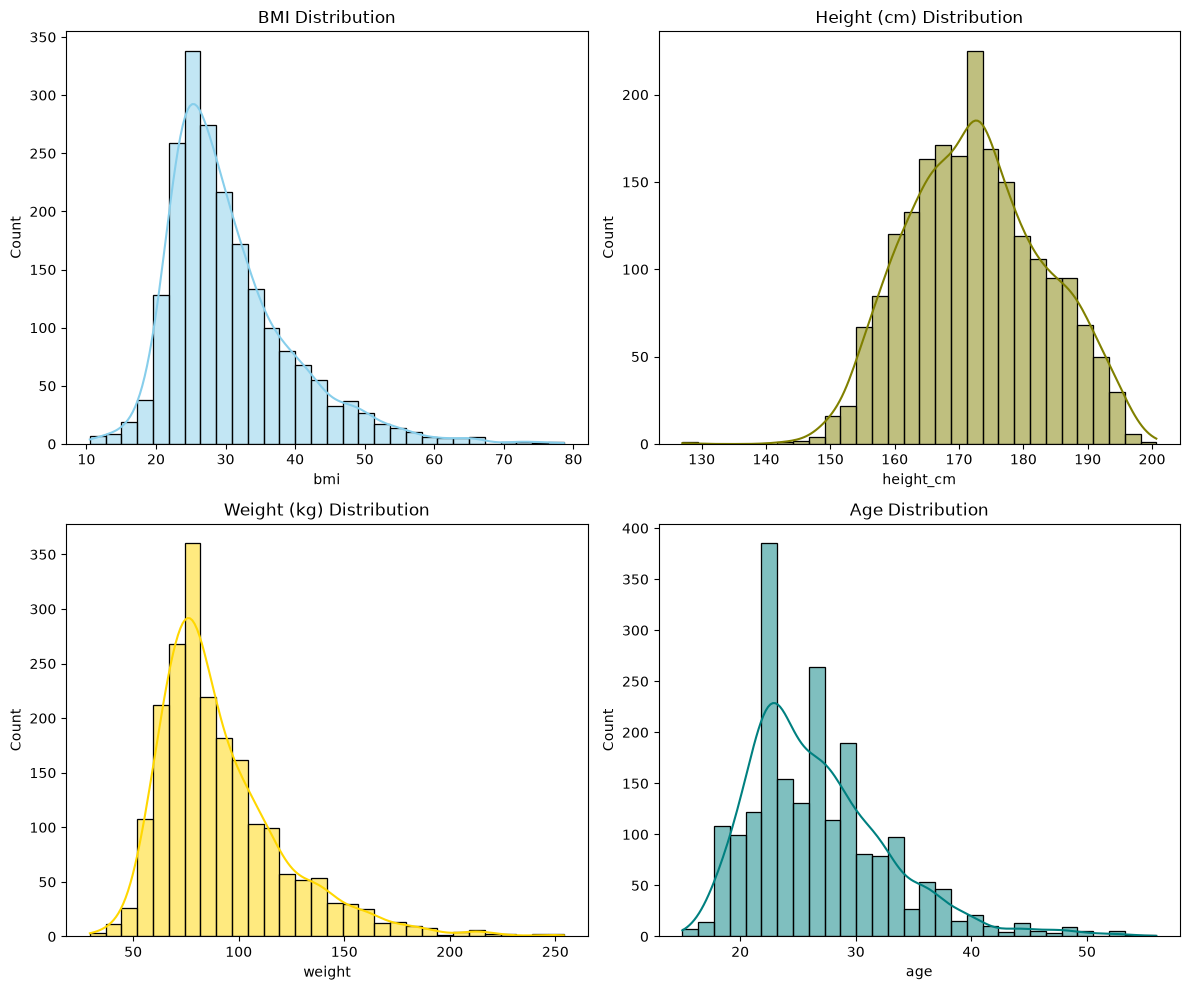

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10)) 

sns.histplot(df_clean['bmi'], bins=30, ax=axes[0, 0], kde=True, color='skyblue')
axes[0, 0].set_title('BMI Distribution')

sns.histplot(df_clean['height_cm'], bins=30, ax=axes[0, 1], kde=True, color='olive')
axes[0, 1].set_title('Height (cm) Distribution') 

sns.histplot(df_clean['weight'], bins=30, ax=axes[1, 0], kde=True, color='gold')
axes[1, 0].set_title('Weight (kg) Distribution') 

sns.histplot(df_clean['age'], bins=30, ax=axes[1, 1], kde=True, color='teal')
axes[1, 1].set_title('Age Distribution') 

plt.tight_layout()
plt.show()

In [24]:
# Applying Domain Bounded Hard Filters

In [25]:
len(df_clean)

2064

### Handling Outliers

In [26]:
df_filtered = df_clean.copy()

In [27]:
#age should be greater or equal to 18 and should be lower than 90

In [28]:
df_filtered = df_filtered[(df_filtered['age'] >= 18) & (df_filtered['age'] <= 90)].copy()

In [29]:
# height between 120cm to 220cm 

In [30]:
df_filtered = df_filtered[(df_filtered['height_cm'] >= 120) & (df_filtered['height_cm'] <= 220)]

In [31]:
# weight between 30 to 200 kgs

In [32]:
df_filtered = df_filtered[(df_filtered['weight'] >= 30) & (df_filtered['weight'] <= 200)]

In [33]:
# bmi range between 12 to 60

In [34]:
df_filtered = df_filtered[(df_filtered['bmi'] >= 12) & (df_filtered['bmi'] <= 60)].copy()

In [35]:
len(df_filtered)

2012

In [36]:
df_filtered.to_csv(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\train_clean_v1.csv", index=False)

In [37]:
# Test Data

In [38]:
df_test = df_test[(df_test['age'] >= 18) & (df_test['age'] <= 90)]
df_test = df_test[(df_test['height_cm'] >= 120) & (df_test['height_cm'] <= 220)]
df_test = df_test[(df_test['weight'] >= 30) & (df_test['weight'] <= 200)]
df_test = df_test[(df_test['bmi'] >= 12) & (df_test['bmi'] <= 60)] 

## FEATURE ENGINEERING

### Target Scaling 

In [39]:
import os
import joblib
from sklearn.preprocessing import StandardScaler 

df_train = pd.read_csv(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\train_split.csv")
df_test = pd.read_csv(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\test_engineered_v1.csv")

In [40]:
df_test.shape , df_train.shape

((873, 8), (2012, 8))

In [41]:
# Storing the Scaler 

In [42]:
os.makedirs(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\preprocessing", exist_ok=True)

In [43]:
## Target Scaling.

In [44]:
targets_to_scale = ['height_cm', 'weight']

for col in targets_to_scale:
    scaler = StandardScaler()
    
    df_train[f'{col}_scaled'] = scaler.fit_transform(df_train[[col]])
    df_test[f'{col}_scaled'] = scaler.transform(df_test[[col]])
    
    scaler_path = rf"C:\Users\mishr\PROJECTS\P4-PulseFit\models\preprocessing\{col}_scaler.pkl"
    joblib.dump(scaler, scaler_path)

In [45]:
df_train.to_csv(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\train_final.csv", index=False)
df_test.to_csv(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\test_final.csv", index=False)

In [46]:
df_train.head()

,image_name,bmi,gender,age,weight,height_cm,bmi_category,bmi_category_encoded,height_cm_scaled,weight_scaled
0,001197_M_18_180340_5443109.jpg,16.736433,1,18,54.43109,180.34,Underweight,3,0.721418,-1.325634
1,0_M_33_187960_19277677.jpg,54.566215,1,33,192.77677,187.96,Obese,1,1.434928,3.770727
2,000558_M_33_172720_11403313.jpg,38.224850,1,33,114.03313,172.72,Obese,1,0.007908,0.869978
3,000614_M_40_175260_9071848.jpg,29.534536,1,40,90.71848,175.26,Overweight,2,0.245745,0.011116
4,000728_F_28_167640_8391459.jpg,29.859475,0,28,83.91459,167.64,Overweight,2,-0.467765,-0.239525


## DataLoader & Data Pipeline 

In [47]:
# Multi output batching

In [48]:
import torch
from torch.utils.data import Dataset
from PIL import Image


class BiometricDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        
        self.image_names = df['image_name'].values
        self.height = df['height_cm_scaled'].values
        self.weight = df['weight_scaled'].values

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        raw_name = str(self.image_names[idx]).strip()
        raw_name = raw_name.replace(']', '').replace('[', '')
        
        img_path = os.path.join(self.img_dir, raw_name)
        
        if not os.path.exists(img_path):
            base_name = os.path.splitext(raw_name)[0]
            found = False
            for ext in ['.jpg', '.jpeg', '.png']:
                test_path = os.path.join(self.img_dir, base_name + ext)
                if os.path.exists(test_path):
                    img_path = test_path
                    found = True
                    break
            if not found:
                raise FileNotFoundError(f"Could not resolve image file for: {raw_name}")
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        targets = {
            "height_out": torch.tensor(self.height[idx], dtype=torch.float32),
            "weight_out": torch.tensor(self.weight[idx], dtype=torch.float32)
        }
        return image, targets

In [49]:
# purging ( deleting ) the files that dont exist in image_train

In [50]:
train_csv_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\train_final.csv"
train_img_dir = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_train"

df_check = pd.read_csv(train_csv_path)

def image_exists(img_name):
    img_path = os.path.join(train_img_dir, str(img_name))
    if os.path.exists(img_path): 
        return True
    
    base = str(img_name).split('.')[0]
    for ext in ['.jpg', '.jpeg', '.png']:
        if os.path.exists(os.path.join(train_img_dir, base + ext)): 
            return True
    return False

df_check['exists'] = df_check['image_name'].apply(image_exists)
df_clean = df_check[df_check['exists'] == True].drop(columns=['exists'])

print(f"Purged {len(df_check) - len(df_clean)} missing ghost images.")

df_clean.to_csv(train_csv_path, index=False)

Purged 1 missing ghost images.


## Merging the Train and test Data Set (for cross validation ) since i have low data

In [51]:
train_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\train_clean_v1.csv"
test_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\test_engineered_v1.csv"

df_tr = pd.read_csv(train_path)
df_te = pd.read_csv(test_path)

df_master = pd.concat([df_tr, df_te], ignore_index=True)
print(f"Master Dataset Combined Shape: {df_master.shape}")

os.makedirs(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\preprocessing", exist_ok=True)
targets_to_scale = ['height_cm', 'weight']

for col in targets_to_scale:
    scaler = StandardScaler()
    df_master[f'{col}_scaled'] = scaler.fit_transform(df_master[[col]])
    
    scaler_path = rf"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\preprocessing\{col}_scaler.pkl"
    joblib.dump(scaler, scaler_path)

master_csv_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\master_dataset.csv"
df_master.to_csv(master_csv_path, index=False)
print(f"Master dataset saved successfully at: {master_csv_path}")

Master Dataset Combined Shape: (2885, 8)
Master dataset saved successfully at: C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\master_dataset.csv


In [52]:
# Data Augmentation and Transformation 

In [53]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10), 
    transforms.RandomAffine(
        degrees=0,          
        translate=(0.05, 0.05), 
        scale=(0.90, 1.10)      
    ),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [54]:
#Train Loader

In [55]:
from torch.utils.data import random_split, DataLoader

train_img_dir = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_train"
master_csv_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\master_dataset.csv"

full_dataset = BiometricDataset(
    csv_file=master_csv_path, 
    img_dir=train_img_dir, 
    transform=train_transform
)

total_size = len(full_dataset)
val_size = 450
train_size = total_size - val_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=True
)

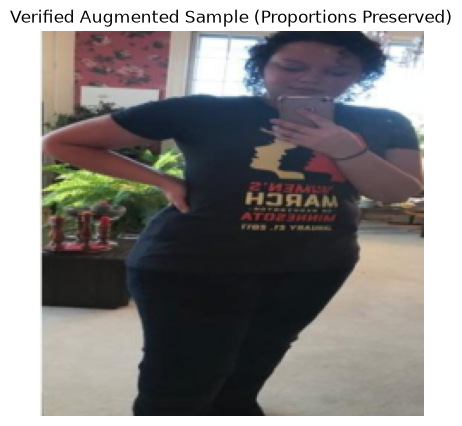

In [56]:
for images, targets in train_loader:
    break

# Denormalize and convert tensor to viewable numpy image
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

sample_img = images[0].permute(1, 2, 0).numpy()
sample_img = (sample_img * std) + mean
sample_img = np.clip(sample_img, 0, 1) 

plt.figure(figsize=(5, 5))
plt.imshow(sample_img)
plt.title("Verified Augmented Sample (Proportions Preserved)")
plt.axis('off')
plt.show()

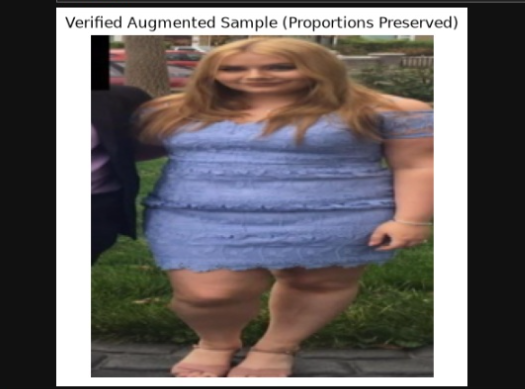
This Girl must not look like this its stretched pic and if we train our model on these then it will predict her to be fat but we can see her pic is stretched making her look fat

If i train a neural network on horizontally stretched images, the model would learn corrupted body geometries. It would look at a stretched, normal-weight person, see a wider waistline caused by bad math, and falsely predict a higher BMI

### SQUARE PADDING ( to fix this problem )

In [57]:
import joblib
from sklearn.preprocessing import StandardScaler
import torchvision.transforms.functional as TF
from torchvision import transforms

class SquarePad:
    def __call__(self, img):
        w, h = img.size
        max_wh = max(w, h)
        hp = (max_wh - w) // 2
        vp = (max_wh - h) // 2
        padding = (hp, vp, max_wh - w - hp, max_wh - h - vp)
        return TF.pad(img, padding, fill=0, padding_mode='constant')

train_transform_padded = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(
        degrees=0, 
        translate=(0.05, 0.05),
        scale=(0.90, 1.10)
    ),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform_padded = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [58]:
train_img_dir = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_train"
master_csv_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\master_dataset.csv"

padded_dataset = BiometricDataset(
    csv_file=master_csv_path, 
    img_dir=train_img_dir, 
    transform=train_transform_padded
) 

total_size = len(padded_dataset)
val_size = 450
train_size = total_size - val_size

train_dataset, val_dataset = random_split(padded_dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transform_padded

In [59]:
## Train Validation Split and DataLoader

In [60]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=True
)

In [61]:
import time 

print("Running DataLoader Benchmark")
start_time = time.time()
batch_count = 10

for i, (images, targets) in enumerate(train_loader):
    if i >= batch_count:
        break

elapsed = time.time() - start_time
batches_per_sec = batch_count / elapsed

print(f"Pipeline Speed: {batches_per_sec:.2f} Batches/Second")
print(f"Batch Tensor Shape: {images.shape}")
print(f"Target Keys Verified: {list(targets.keys())}")

Running DataLoader Benchmark
Pipeline Speed: 1.33 Batches/Second
Batch Tensor Shape: torch.Size([32, 3, 224, 224])
Target Keys Verified: ['height_out', 'weight_out']


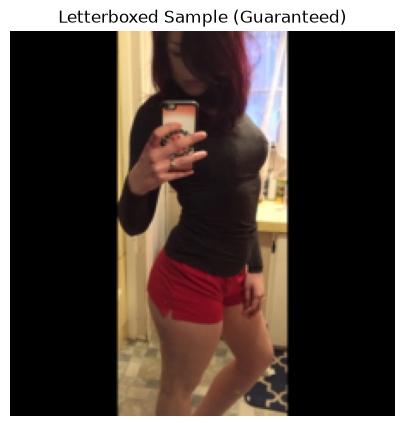

In [62]:
for images, targets in train_loader:
    break 

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

sample_img = images[0].permute(1, 2, 0).numpy()
sample_img = (sample_img * std) + mean
sample_img = np.clip(sample_img, 0, 1) 

plt.figure(figsize=(5, 5))
plt.imshow(sample_img)
plt.title("Letterboxed Sample (Guaranteed)")
plt.axis('off')
plt.show()

### Using Pre-trained models to remove background

Loading Pre-Trained DeepLabV3 Segmentation Model
testing on image: 001197_M_18_180340_5443109.jpg


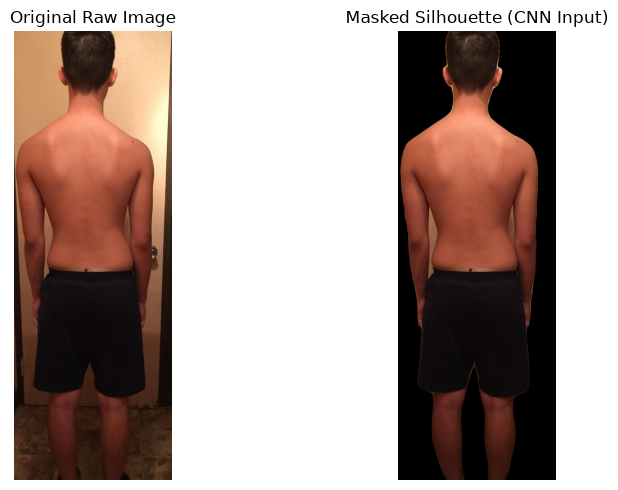

In [63]:
import torch
from PIL import Image
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Loading Pre-Trained DeepLabV3 Segmentation Model")

# Load Native PyTorch Human Segmentation Model
seg_model = deeplabv3_resnet101(weights=DeepLabV3_ResNet101_Weights.DEFAULT).to(device)
seg_model.eval()

preprocess = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

master_csv_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\master_dataset.csv"
raw_img_dir = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_train"

df_master = pd.read_csv(master_csv_path)
test_img_name = str(df_master['image_name'].iloc[0]).strip().replace('[', '').replace(']', '')
in_path = os.path.join(raw_img_dir, test_img_name)

print(f"testing on image: {test_img_name}")
img = Image.open(in_path).convert("RGB")
input_tensor = preprocess(img).unsqueeze(0).to(device)

# Run Inference
with torch.no_grad():
    output = seg_model(input_tensor)['out'][0]

# Class 15 in DeepLabV3 COCO dataset is 'Person'
person_mask = (output.argmax(0) == 15).cpu().numpy()

# Apply mask: Set everything that is NOT the person to Black [0,0,0]
img_array = np.array(img)
img_array[~person_mask] = [0, 0, 0] 
masked_img = Image.fromarray(img_array)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[0].set_title("Original Raw Image")
axes[0].axis("off")

axes[1].imshow(masked_img)
axes[1].set_title("Masked Silhouette (CNN Input)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [65]:
from PIL import Image
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights
from tqdm import tqdm
import pandas as pd
import gc 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device Engine on: {device}")

raw_img_dir = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_train"
masked_img_dir = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_train_masked"
os.makedirs(masked_img_dir, exist_ok=True)
master_csv_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\master_dataset.csv"

print("Loading Human Parsing Weights")
seg_model = deeplabv3_resnet101(weights=DeepLabV3_ResNet101_Weights.DEFAULT).to(device)
seg_model.eval()

preprocess = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

df_master = pd.read_csv(master_csv_path)

print(f"Extracting clean silhouettes for {len(df_master)} images...")
for i, img_name in enumerate(tqdm(df_master['image_name'].values)):
    clean_name = str(img_name).strip().replace('[', '').replace(']', '')
    in_path = os.path.join(raw_img_dir, clean_name)
    out_path = os.path.join(masked_img_dir, clean_name)
    
    if os.path.exists(out_path) or not os.path.exists(in_path):
        continue
        
    try:
        img = Image.open(in_path).convert("RGB")
        input_tensor = preprocess(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = seg_model(input_tensor)['out'][0]
        
        person_mask = (output.argmax(0) == 15).cpu().numpy()
        
        img_array = np.array(img)
        img_array[~person_mask] = [0, 0, 0]
        
        masked_img = Image.fromarray(img_array)
        masked_img.save(out_path)
        
        # --- STRICT MEMORY MANAGEMENT ---
        img.close()
        del input_tensor, output, person_mask, img_array, masked_img
        
    except Exception as e:
        print(f"\nSkipping problematic image {clean_name}: {e}")
        continue
        
    # Flush memory caches every 50 images to prevent Kernel crashes
    if i % 50 == 0:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("All backgrounds removed. Dataset masked successfully")

Device Engine on: cuda
Loading Human Parsing Weights
Extracting clean silhouettes for 2885 images...


100%|██████████| 2885/2885 [00:00<00:00, 31948.69it/s]

All backgrounds removed. Dataset masked successfully


## Version 3 ( Pre-trained models + Optuna + Calibration )

In [66]:
### pre trained background removal and silhouette extraction 

In [67]:
from PIL import Image
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights
from tqdm import tqdm
import pandas as pd
import gc 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device Engine on: {device}")

raw_img_dir = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_train"
masked_img_dir = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_train_masked"
os.makedirs(masked_img_dir, exist_ok=True)
master_csv_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\master_dataset.csv"

print("Loading Human Parsing Weights")
seg_model = deeplabv3_resnet101(weights=DeepLabV3_ResNet101_Weights.DEFAULT).to(device)
seg_model.eval()

preprocess = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

df_master = pd.read_csv(master_csv_path)

print(f"Extracting clean silhouettes for {len(df_master)} images...")
for i, img_name in enumerate(tqdm(df_master['image_name'].values)):
    clean_name = str(img_name).strip().replace('[', '').replace(']', '')
    in_path = os.path.join(raw_img_dir, clean_name)
    out_path = os.path.join(masked_img_dir, clean_name)
    
    if os.path.exists(out_path) or not os.path.exists(in_path):
        continue
        
    try:
        img = Image.open(in_path).convert("RGB")
        input_tensor = preprocess(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = seg_model(input_tensor)['out'][0]
        
        person_mask = (output.argmax(0) == 15).cpu().numpy()
        
        img_array = np.array(img)
        img_array[~person_mask] = [0, 0, 0]
        
        masked_img = Image.fromarray(img_array)
        masked_img.save(out_path)
        
        img.close()
        del input_tensor, output, person_mask, img_array, masked_img
        
    except Exception as e:
        print(f"\nSkipping problematic image {clean_name}: {e}")
        continue
        
    # Flush memory caches every 50 images to prevent Kernel crashes
    if i % 50 == 0:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("All backgrounds removed. Dataset masked successfully")

Device Engine on: cuda
Loading Human Parsing Weights
Extracting clean silhouettes for 2885 images...


100%|██████████| 2885/2885 [00:00<00:00, 34967.99it/s]

All backgrounds removed. Dataset masked successfully


In [68]:
## Dataloader for masked silhouette

In [69]:
from torch.utils.data import random_split, DataLoader

masked_img_dir = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_train_masked"

masked_full_dataset = BiometricDataset(
    csv_file=master_csv_path, 
    img_dir=masked_img_dir, 
    transform=train_transform
)

total_size = len(masked_full_dataset)
val_size = 450
train_size = total_size - val_size

train_dataset, val_dataset = random_split(masked_full_dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print(f"Masked DataLoaders Ready: {len(train_dataset)} Train | {len(val_dataset)} Validation")

Masked DataLoaders Ready: 2435 Train | 450 Validation


In [70]:
## transfer learning model

In [71]:
import torch.nn as nn
import torchvision.models as models
from sklearn.metrics import mean_absolute_error

scaler_h = joblib.load(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\preprocessing\height_cm_scaler.pkl")
scaler_w = joblib.load(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\preprocessing\weight_scaler.pkl")

class BiometricRegressor(nn.Module):
    def __init__(self, dropout_rate=0.4):
        super(BiometricRegressor, self).__init__()
        base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_features = base.classifier[1].in_features
        self.feature_extractor = base.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        self.shared_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(p=dropout_rate)
        )
        
        self.head_height = nn.Sequential(nn.Linear(256, 64), nn.SiLU(), nn.Linear(64, 1))
        self.head_weight = nn.Sequential(nn.Linear(256, 64), nn.SiLU(), nn.Linear(64, 1))

    def forward(self, x):
        feat = self.pool(self.feature_extractor(x))
        shared = self.shared_fc(feat)
        return {'height_out': self.head_height(shared).squeeze(-1), 'weight_out': self.head_weight(shared).squeeze(-1)}

def evaluate_metrics(y_h_true, y_h_pred, y_w_true, y_w_pred):
    h_true = scaler_h.inverse_transform(np.array(y_h_true).reshape(-1, 1)).flatten()
    h_pred = scaler_h.inverse_transform(np.array(y_h_pred).reshape(-1, 1)).flatten()
    w_true = scaler_w.inverse_transform(np.array(y_w_true).reshape(-1, 1)).flatten()
    w_pred = scaler_w.inverse_transform(np.array(y_w_pred).reshape(-1, 1)).flatten()
    return {'H_MAE': mean_absolute_error(h_true, h_pred), 'W_MAE': mean_absolute_error(w_true, w_pred)}

In [72]:
# Deep optuna based hyperparameter tuning 

In [73]:
import optuna
from torch.cuda.amp import GradScaler, autocast

def optuna_objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 5e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.3, 0.6)
    w_penalty = trial.suggest_float("weight_penalty", 1.5, 3.0) 

    model = BiometricRegressor(dropout_rate=dropout_rate).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    criterion = nn.SmoothL1Loss()
    scaler = GradScaler()
    
    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(40):
        model.train()
        for images, targets in train_loader:
            images = images.to(device, non_blocking=True)
            h_t = targets['height_out'].to(device, non_blocking=True)
            w_t = targets['weight_out'].to(device, non_blocking=True)
            
            optimizer.zero_grad()
            with autocast():
                out = model(images)
                loss = criterion(out['height_out'], h_t) + (w_penalty * criterion(out['weight_out'], w_t))
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, targets in val_loader:
                images, h_t, w_t = images.to(device), targets['height_out'].to(device), targets['weight_out'].to(device)
                with autocast():
                    out = model(images)
                    loss = criterion(out['height_out'], h_t) + (w_penalty * criterion(out['weight_out'], w_t))
                val_loss += loss.item() * images.size(0)
                
        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)
        
        # Early Stopping for Optuna Trials
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 5: break
            
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    return best_loss

print("Launching Heavy-Duty Optuna Search")
study = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=10))
study.optimize(optuna_objective, n_trials=20) 

best_params = study.best_trial.params
print(f"\nBest Optuna Parameters: {best_params}")

C:\Users\mishr\anaconda3\envs\ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-26 18:09:22,525] A new study created in memory with name: no-name-ad4592e0-79f5-4c0f-b361-b25dd3fc8a2b


Launching Heavy-Duty Optuna Search


C:\Users\mishr\AppData\Local\Temp\ipykernel_44328\1164986360.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\mishr\AppData\Local\Temp\ipykernel_44328\1164986360.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\mishr\AppData\Local\Temp\ipykernel_44328\1164986360.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
[I 2026-08-26 18:33:49,244] Trial 0 finished with value: 0.800118874443902 and parameters: {'lr': 5.5199831167429084e-05, 'weight_decay': 0.005071191853066645, 'dropout_rate': 0.4593827801275407, 'weight_penalty': 2.4089755741932923}. Best is trial 0 with value: 0.800118874443902.
[I 2026-08-26 18:39:54,337] Trial 1 finished with value: 0.7685703784889645 and


Best Optuna Parameters: {'lr': 0.0004762704361725424, 'weight_decay': 1.4627996488887153e-05, 'dropout_rate': 0.4468399928358825, 'weight_penalty': 1.5573616821754792}


In [74]:
# model optimization

In [75]:
final_model = BiometricRegressor(dropout_rate=best_params['dropout_rate']).to(device)
optimizer = torch.optim.AdamW(final_model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
criterion = nn.SmoothL1Loss()
scaler = GradScaler()
w_penalty = best_params['weight_penalty']

best_val_loss = float('inf')
save_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\checkpoints\pulsefit_golden_model.pth"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

for epoch in range(1, 101):
    final_model.train()
    for images, targets in train_loader:
        images, h_t, w_t = images.to(device), targets['height_out'].to(device), targets['weight_out'].to(device)
        optimizer.zero_grad()
        with autocast():
            out = final_model(images)
            loss = criterion(out['height_out'], h_t) + (w_penalty * criterion(out['weight_out'], w_t))
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
    final_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images, h_t, w_t = images.to(device), targets['height_out'].to(device), targets['weight_out'].to(device)
            with autocast():
                out = final_model(images)
                loss = criterion(out['height_out'], h_t) + (w_penalty * criterion(out['weight_out'], w_t))
            val_loss += loss.item() * images.size(0)
            
    val_loss /= len(val_loader.dataset)
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(final_model.state_dict(), save_path)
        print(f"Epoch {epoch:03d} | New Best Val Loss: {val_loss:.4f} - Saved!")

print(f"Final Model Trained and Saved to {save_path}")

C:\Users\mishr\AppData\Local\Temp\ipykernel_44328\4193876499.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\mishr\AppData\Local\Temp\ipykernel_44328\4193876499.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\mishr\AppData\Local\Temp\ipykernel_44328\4193876499.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 001 | New Best Val Loss: 0.6983 - Saved!
Epoch 004 | New Best Val Loss: 0.6865 - Saved!
Epoch 005 | New Best Val Loss: 0.6713 - Saved!
Epoch 007 | New Best Val Loss: 0.6528 - Saved!
Epoch 009 | New Best Val Loss: 0.6481 - Saved!
Epoch 010 | New Best Val Loss: 0.6348 - Saved!
Epoch 012 | New Best Val Loss: 0.6148 - Saved!
Epoch 019 | New Best Val Loss: 0.6010 - Saved!
Epoch 021 | New Best Val Loss: 0.5957 - Saved!
Epoch 030 | New Best Val Loss: 0.5907 - Saved!
Epoch 034 | New Best Val Loss: 0.5860 - Saved!
Epoch 035 | New Best Val Loss: 0.5846 - Saved!
Epoch 063 | New Best Val Loss: 0.5837 - Saved!
Final Model Trained and Saved to C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\checkpoints\pulsefit_golden_model.pth


In [76]:
# Model post processing and calibration 

In [77]:
from sklearn.linear_model import Ridge

print("Calibrating Predictions")
final_model.load_state_dict(torch.load(save_path))
final_model.eval()

raw_h_true, raw_h_pred, raw_w_true, raw_w_pred = [], [], [], []

with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(device)
        with autocast():
            out = final_model(images)
            
        raw_h_true.extend(targets['height_out'].numpy())
        raw_h_pred.extend(out['height_out'].cpu().numpy())
        raw_w_true.extend(targets['weight_out'].numpy())
        raw_w_pred.extend(out['weight_out'].cpu().numpy())

h_raw_true = scaler_h.inverse_transform(np.array(raw_h_true).reshape(-1, 1)).flatten()
h_raw_pred = scaler_h.inverse_transform(np.array(raw_h_pred).reshape(-1, 1)).flatten()
w_raw_true = scaler_w.inverse_transform(np.array(raw_w_true).reshape(-1, 1)).flatten()
w_raw_pred = scaler_w.inverse_transform(np.array(raw_w_pred).reshape(-1, 1)).flatten()

calibrator_h = Ridge(alpha=1.0).fit(h_raw_pred.reshape(-1, 1), h_raw_true)
calibrator_w = Ridge(alpha=1.0).fit(w_raw_pred.reshape(-1, 1), w_raw_true)

joblib.dump(calibrator_h, r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\preprocessing\calibrator_height.pkl")
joblib.dump(calibrator_w, r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\preprocessing\calibrator_weight.pkl")

h_calib_pred = calibrator_h.predict(h_raw_pred.reshape(-1, 1))
w_calib_pred = calibrator_w.predict(w_raw_pred.reshape(-1, 1))

print(f"FINAL CALIBRATED ERROR:")
print(f"Height Error: ±{mean_absolute_error(h_raw_true, h_calib_pred):.2f} cm")
print(f"Weight Error: ±{mean_absolute_error(w_raw_true, w_calib_pred):.2f} kg")

# BMI Error
bmi_true = w_raw_true / ((h_raw_true / 100.0) ** 2)
bmi_pred = w_calib_pred / ((h_calib_pred / 100.0) ** 2)
print(f"BMI Error: ±{mean_absolute_error(bmi_true, bmi_pred):.2f}")

Calibrating Predictions


C:\Users\mishr\AppData\Local\Temp\ipykernel_44328\3183600291.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


FINAL CALIBRATED ERROR:
Height Error: ±6.88 cm
Weight Error: ±12.47 kg
BMI Error: ±3.52


## Bodyfat Calculation ( using Deurenberg Formula )

In [67]:
import gc

class PulseFitEngine:
    def __init__(
        self,
        checkpoint_path=r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\checkpoints\pulsefit_golden_model.pth",
        preprocessing_dir=r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\preprocessing",
        device=None
    ):
        self.device = device if device else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Initializing PulseFit Production Engine on: {self.device}")
        
        print("Loading DeepLabV3 Segmentation Model...")
        self.seg_model = deeplabv3_resnet101(weights=DeepLabV3_ResNet101_Weights.DEFAULT).to(self.device)
        self.seg_model.eval()
        
        self.seg_preprocess = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        print("Loading Scalers and Calibrators...")
        self.scaler_h = joblib.load(os.path.join(preprocessing_dir, "height_cm_scaler.pkl"))
        self.scaler_w = joblib.load(os.path.join(preprocessing_dir, "weight_scaler.pkl"))
        self.calibrator_h = joblib.load(os.path.join(preprocessing_dir, "calibrator_height.pkl"))
        self.calibrator_w = joblib.load(os.path.join(preprocessing_dir, "calibrator_weight.pkl"))
        
        print("Loading Golden Biometric Regressor Weights...")
        self.regressor = BiometricRegressor(dropout_rate=0.4468).to(self.device)
        self.regressor.load_state_dict(torch.load(checkpoint_path, map_location=self.device))
        self.regressor.eval()
        
        self.cnn_transform = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        print("PulseFit Engine Ready for Diagnostics")

    def _extract_silhouette(self, pil_img: Image.Image) -> Image.Image:
        """Removes background noise and returns a clean body silhouette."""
        rgb_img = pil_img.convert("RGB")
        input_tensor = self.seg_preprocess(rgb_img).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            output = self.seg_model(input_tensor)["out"][0]
            
        person_mask = (output.argmax(0) == 15).cpu().numpy()
        img_array = np.array(rgb_img)
        img_array[~person_mask] = [0, 0, 0]  # Blackout background
        
        masked_pil = Image.fromarray(img_array)
        return masked_pil

    def _classify_bmi(self, bmi: float) -> str:
        if bmi < 18.5:
            return "Underweight"
        elif 18.5 <= bmi < 25.0:
            return "Normal Weight"
        elif 25.0 <= bmi < 30.0:
            return "Overweight"
        else:
            return "Obese"

    def _classify_body_fat(self, bf: float, gender_num: int) -> str:
        if gender_num == 1:  # Male
            if bf < 6: return "Essential Fat"
            elif bf <= 13: return "Athletic"
            elif bf <= 17: return "Fitness"
            elif bf <= 24: return "Average"
            else: return "Obese"
        else:  # Female
            if bf < 14: return "Essential Fat"
            elif bf <= 20: return "Athletic"
            elif bf <= 24: return "Fitness"
            elif bf <= 31: return "Average"
            else: return "Obese"

    def predict(self, image_input, age: int, gender: str or int) -> dict:
        if isinstance(gender, str):
            gender_clean = gender.strip().lower()
            if gender_clean in ['m', 'male', '1']:
                gender_num = 1
                gender_label = "Male"
            elif gender_clean in ['f', 'female', '0']:
                gender_num = 0
                gender_label = "Female"
            else:
                raise ValueError("Gender must be 'Male'/'M'/1 or 'Female'/'F'/0.")
        else:
            gender_num = int(gender)
            gender_label = "Male" if gender_num == 1 else "Female"

        if isinstance(image_input, str):
            if not os.path.exists(image_input):
                raise FileNotFoundError(f"Image not found at path: {image_input}")
            raw_img = Image.open(image_input)
        elif isinstance(image_input, Image.Image):
            raw_img = image_input
        else:
            raise TypeError("image_input must be a file path string or PIL Image.")

        masked_silhouette = self._extract_silhouette(raw_img)

        cnn_tensor = self.cnn_transform(masked_silhouette).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            preds = self.regressor(cnn_tensor)
            scaled_h = preds['height_out'].cpu().numpy().reshape(-1, 1)
            scaled_w = preds['weight_out'].cpu().numpy().reshape(-1, 1)

        raw_h = float(self.scaler_h.inverse_transform(scaled_h)[0][0])
        raw_w = float(self.scaler_w.inverse_transform(scaled_w)[0][0])

        final_h = float(self.calibrator_h.predict([[raw_h]])[0])
        final_w = float(self.calibrator_w.predict([[raw_w]])[0])

        height_m = final_h / 100.0
        bmi = final_w / (height_m ** 2)

        body_fat_pct = (1.20 * bmi) + (0.23 * float(age)) - (10.8 * float(gender_num)) - 5.4
        body_fat_pct = max(3.0, body_fat_pct)  # Clinical biological minimum floor

        return {
            "Patient Profile": {
                "Age": age,
                "Gender": gender_label
            },
            "Biometric Predictions": {
                "Estimated Height (cm)": round(final_h, 2),
                "Estimated Weight (kg)": round(final_w, 2),
            },
            "Clinical Metrics": {
                "Calculated BMI": round(bmi, 2),
                "BMI Category": self._classify_bmi(bmi),
                "Estimated Body Fat %": round(body_fat_pct, 2),
                "Body Fat Category": self._classify_body_fat(body_fat_pct, gender_num)
            },
            "Processed Silhouette": masked_silhouette
        }

## Checking the Actual vs Predicted weight

After checking the model for actual pictures ( On the vercel site ) i observed that the model is mainly under reporting weights speicfically in heavy weight category. so im running visual plots to confirm the hypothesis 

In [68]:
import torch.nn as nn
import torchvision.models as models

class BiometricRegressor(nn.Module):
    def __init__(self, dropout_rate=0.4):
        super(BiometricRegressor, self).__init__()
        base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_features = base.classifier[1].in_features
        self.feature_extractor = base.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        self.shared_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(p=dropout_rate)
        )
        
        self.head_height = nn.Sequential(nn.Linear(256, 64), nn.SiLU(), nn.Linear(64, 1))
        self.head_weight = nn.Sequential(nn.Linear(256, 64), nn.SiLU(), nn.Linear(64, 1))

    def forward(self, x):
        feat = self.pool(self.feature_extractor(x))
        shared = self.shared_fc(feat)
        return {'height_out': self.head_height(shared).squeeze(-1), 'weight_out': self.head_weight(shared).squeeze(-1)}


ERROR ANALYSIS:
 Raw Model Bias: -12.18 kg
 Calibrated Model Bias: -12.71 kg
  ALERT: Your model is systematically UNDER-REPORTING weight across the board.


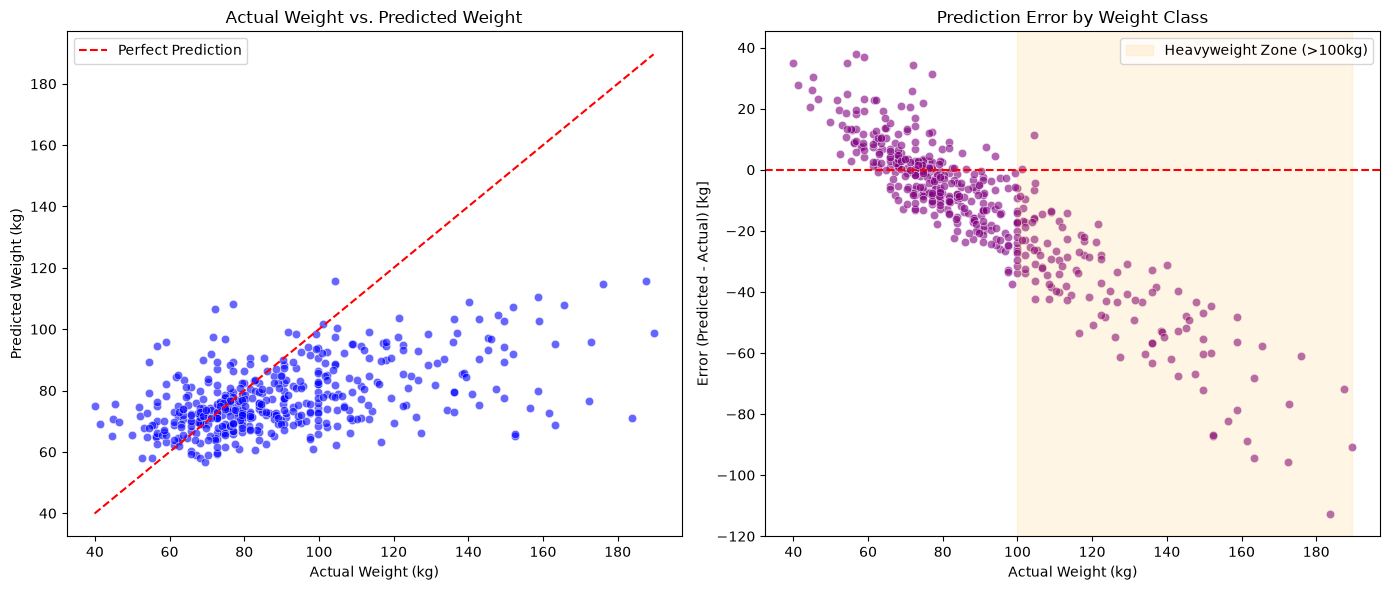

In [70]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
preprocessing_dir = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\preprocessing"
save_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\checkpoints\pulsefit_golden_model.pth"

# 1. Safely Reload the Model and Calibrators from your Hard Drive
final_model = BiometricRegressor(dropout_rate=0.4468).to(device) 
final_model.load_state_dict(torch.load(save_path, map_location=device))
final_model.eval()

scaler_w = joblib.load(os.path.join(preprocessing_dir, "weight_scaler.pkl"))
calibrator_w = joblib.load(os.path.join(preprocessing_dir, "calibrator_weight.pkl"))

true_weights, raw_pred_weights, calib_pred_weights = [], [], []

# 2. Run Inference on Validation Set
with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(device)
        with torch.amp.autocast('cuda'):
            out = final_model(images)
            
        w_t = scaler_w.inverse_transform(targets['weight_out'].numpy().reshape(-1, 1)).flatten()
        true_weights.extend(w_t)
        
        w_p_raw = scaler_w.inverse_transform(out['weight_out'].cpu().numpy().reshape(-1, 1)).flatten()
        raw_pred_weights.extend(w_p_raw)
        
        w_p_calib = calibrator_w.predict(w_p_raw.reshape(-1, 1)).flatten()
        calib_pred_weights.extend(w_p_calib)

true_weights = np.array(true_weights)
raw_pred_weights = np.array(raw_pred_weights)
calib_pred_weights = np.array(calib_pred_weights)

# 3. Calculate Mean Bias Error (MBE)
raw_bias = np.mean(raw_pred_weights - true_weights)
calib_bias = np.mean(calib_pred_weights - true_weights)

print(f"\nERROR ANALYSIS:")
print(f" Raw Model Bias: {raw_bias:.2f} kg")
print(f" Calibrated Model Bias: {calib_bias:.2f} kg")

if calib_bias < -2.0:
    print("  ALERT: Your model is systematically UNDER-REPORTING weight across the board.")

# 4. Visualizing the "Ceiling Effect" (Regression to the Mean)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=true_weights, y=calib_pred_weights, ax=axes[0], alpha=0.6, color="blue")
min_val = min(true_weights.min(), calib_pred_weights.min())
max_val = max(true_weights.max(), calib_pred_weights.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

axes[0].set_title("Actual Weight vs. Predicted Weight")
axes[0].set_xlabel("Actual Weight (kg)")
axes[0].set_ylabel("Predicted Weight (kg)")
axes[0].legend()

residuals = calib_pred_weights - true_weights
sns.scatterplot(x=true_weights, y=residuals, ax=axes[1], alpha=0.6, color="purple")
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title("Prediction Error by Weight Class")
axes[1].set_xlabel("Actual Weight (kg)")
axes[1].set_ylabel("Error (Predicted - Actual) [kg]")

axes[1].axvspan(100, max_val, color='orange', alpha=0.1, label="Heavyweight Zone (>100kg)")
axes[1].legend()

plt.tight_layout()
plt.show()

Hypothesis Confirmed. Model is indeed under reporting

In [71]:
## Advanced Calibration

In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error

print("⚙️ Re-calibrating weight predictions across full dynamic range...")

# 1. Prepare raw arrays from previous diagnostic run
X_val_raw = raw_pred_weights.reshape(-1, 1)
y_val_true = true_weights

# --- Calibrator A: Unregularized OLS Linear Regression ---
calib_ols = LinearRegression().fit(X_val_raw, y_val_true)
pred_ols = calib_ols.predict(X_val_raw)

# --- Calibrator B: 2nd-Degree Polynomial Regression ---
calib_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
calib_poly.fit(X_val_raw, y_val_true)
pred_poly = calib_poly.predict(X_val_raw)

# --- Calibrator C: Isotonic Regression ---
calib_iso = IsotonicRegression(out_of_bounds='clip').fit(raw_pred_weights, y_val_true)
pred_iso = calib_iso.predict(raw_pred_weights)

# --- Calibrator D: Variance Matching (Quantile / Z-Score Stretch) ---
mu_true, std_true = np.mean(y_val_true), np.std(y_val_true)
mu_pred, std_pred = np.mean(raw_pred_weights), np.std(raw_pred_weights)

class VarianceExpander:
    def __init__(self, mu_t, std_t, mu_p, std_p):
        self.mu_t, self.std_t = mu_t, std_t
        self.mu_p, self.std_p = mu_p, std_p
    def predict(self, X):
        X_arr = np.array(X).flatten()
        return self.mu_t + (X_arr - self.mu_p) * (self.std_t / self.std_p)

calib_var = VarianceExpander(mu_true, std_true, mu_pred, std_pred)
pred_var = calib_var.predict(raw_pred_weights)

# 2. Performance Comparison Table
heavy_mask = y_val_true >= 100.0

results = []
models_dict = {
    "Original Ridge (Old)": (calib_pred_weights, None),
    "OLS Linear": (pred_ols, calib_ols),
    "Polynomial (Degree 2)": (pred_poly, calib_poly),
    "Isotonic Regression": (pred_iso, calib_iso),
    "Variance Expander": (pred_var, calib_var)
}

for name, (preds, model_obj) in models_dict.items():
    overall_mae = mean_absolute_error(y_val_true, preds)
    overall_bias = np.mean(preds - y_val_true)
    heavy_mae = mean_absolute_error(y_val_true[heavy_mask], preds[heavy_mask])
    heavy_bias = np.mean(preds[heavy_mask] - y_val_true[heavy_mask])
    results.append({
        "Model": name,
        "Overall MAE (kg)": round(overall_mae, 2),
        "Overall Bias (kg)": round(overall_bias, 2),
        "Heavy (>100kg) MAE": round(heavy_mae, 2),
        "Heavy (>100kg) Bias": round(heavy_bias, 2)
    })

df_results = pd.DataFrame(results).sort_values("Heavy (>100kg) MAE")
print("\n" + "="*70)
print("              CALIBRATOR BENCHMARK COMPARISON TABLE              ")
print("="*70)
print(df_results.to_string(index=False))
print("="*70)

# 3. Save the Best Performing Calibrator
best_model_name = df_results.iloc[0]["Model"]
best_calibrator = models_dict[best_model_name][1]

save_calib_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\preprocessing\calibrator_weight.pkl"
joblib.dump(best_calibrator, save_calib_path)
print(f"\n🏆 Saved best calibrator [{best_model_name}] to: {save_calib_path}")

# 4. Verification Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

best_preds = models_dict[best_model_name][0]

sns.scatterplot(x=y_val_true, y=best_preds, ax=axes[0], color="green", alpha=0.6)
axes[0].plot([y_val_true.min(), y_val_true.max()], [y_val_true.min(), y_val_true.max()], 'r--', label="Perfect (1:1)")
axes[0].set_title(f"Recalibrated with {best_model_name}")
axes[0].set_xlabel("Actual Weight (kg)")
axes[0].set_ylabel("Predicted Weight (kg)")
axes[0].legend()

residuals_new = best_preds - y_val_true
sns.scatterplot(x=y_val_true, y=residuals_new, ax=axes[1], color="teal", alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].axvspan(100, y_val_true.max(), color="orange", alpha=0.1, label="Heavyweight Zone (>100kg)")
axes[1].set_title("Recalibrated Residual Errors")
axes[1].set_xlabel("Actual Weight (kg)")
axes[1].set_ylabel("Error (Predicted - Actual) [kg]")
axes[1].legend()

plt.tight_layout()
plt.show()